### **Image Classification Using EfficientNet B0 with Imagenet pretrained Model**

- **To use EfficientNetB0 for classifying 1000 classes of images from imagenet, we can use Imagenet weights.**

In [1]:
from tensorflow.keras.applications import EfficientNetB0
model = EfficientNetB0(weights='imagenet')

21834768/21834768 ━━━━━━━━━━━━━━━━━━━━ 11s 1us/step


In [2]:
model.summary()

Model: "efficientnetb0"

┏━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃                ┃              ┃  Param ┃               ┃
┃ Layer (type)   ┃ Output Shape ┃      # ┃ Connected to  ┃
┡━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer    │ (None, 224,  │      0 │ -             │
│ (InputLayer)   │ 224, 3)      │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ rescaling      │ (None, 224,  │      0 │ input_layer[… │
│ (Rescaling)    │ 224, 3)      │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ normalization  │ (None, 224,  │      7 │ rescaling[0]… │
│ (Normalizatio… │ 224, 3)      │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ rescaling_1    │ (None, 224,  │      0 │ normalizatio… │
│ (Rescaling)    │ 224, 3)      │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ stem_conv_pad  │ (None, 225,  │      0 │ rescaling_1[… │
│ (ZeroPadding2… │ 225, 3)      │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ stem_conv      │ (None, 112,  │    864 │ stem_conv_pa… │
│ (Conv2D)       │ 112, 32)     │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ stem_bn        │ (None, 112,  │    128 │ stem_conv[0]… │
│ (BatchNormali… │ 112, 32)     │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ stem_activati… │ (None, 112,  │      0 │ stem_bn[0][0] │
│ (Activation)   │ 112, 32)     │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ block1a_dwconv │ (None, 112,  │    288 │ stem_activat… │
│ (DepthwiseCon… │ 112, 32)     │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ block1a_bn     │ (None, 112,  │    128 │ block1a_dwco… │
│ (BatchNormali… │ 112, 32)     │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ block1a_activ… │ (None, 112,  │      0 │ block1a_bn[0… │
│ (Activation)   │ 112, 32)     │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ block1a_se_sq… │ (None, 32)   │      0 │ block1a_acti… │
│ (GlobalAverag… │              │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ block1a_se_re… │ (None, 1, 1, │      0 │ block1a_se_s… │
│ (Reshape)      │ 32)          │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ block1a_se_re… │ (None, 1, 1, │    264 │ block1a_se_r… │
│ (Conv2D)       │ 8)           │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ block1a_se_ex… │ (None, 1, 1, │    288 │ block1a_se_r… │
│ (Conv2D)       │ 32)          │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ block1a_se_ex… │ (None, 112,  │      0 │ block1a_acti… │
│ (Multiply)     │ 112, 32)     │        │ block1a_se_e… │
├────────────────┼──────────────┼────────┼───────────────┤
│ block1a_proje… │ (None, 112,  │    512 │ block1a_se_e… │
│ (Conv2D)       │ 112, 16)     │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ block1a_proje… │ (None, 112,  │     64 │ block1a_proj… │
│ (BatchNormali… │ 112, 16)     │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ block2a_expan… │ (None, 112,  │  1,536 │ block1a_proj… │
│ (Conv2D)       │ 112, 96)     │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ block2a_expan… │ (None, 112,  │    384 │ block2a_expa… │
│ (BatchNormali… │ 112, 96)     │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ block2a_expan… │ (None, 112,  │      0 │ block2a_expa… │
│ (Activation)   │ 112, 96)     │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ block2a_dwcon… │ (None, 113,  │      0 │ bloc

 Total params: 5,330,571 (20.33 MB)

 Trainable params: 5,288,548 (20.17 MB)

 Non-trainable params: 42,023 (164.16 KB)

In [20]:
import cv2
import numpy as np
from matplotlib.pyplot import imread
from matplotlib.pyplot import imshow
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.imagenet_utils import decode_predictions
from tensorflow.keras.applications.imagenet_utils import preprocess_input

import cv2
import os

img_path = r'Downloads\cat.JPEG'

print("Exists:", os.path.exists(img_path))

img = cv2.imread(img_path)
print("Image loaded:", img is not None)

Exists: True
Image loaded: True


Input image shape: (1, 224, 224, 3)


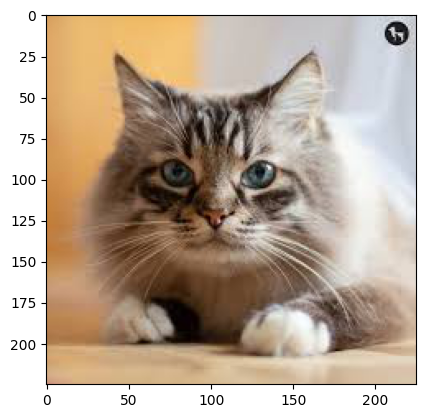

In [21]:
img = cv2.imread(img_path)
img = cv2.resize(img, (224, 224))

x = np.expand_dims(img, axis=0)
x = preprocess_input(x)

print('Input image shape:', x.shape)

my_image = imread(img_path)
imshow(my_image)

- **probabilities for being in each of the 1000 classes**

In [22]:
preds=model.predict(x)
print("predicted class: ", preds )

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
predicted class:  [[1.19924654e-04 2.17712281e-04 5.93798395e-05 1.35862632e-04
  6.13715893e-05 5.68323303e-04 1.29564898e-04 6.59809593e-05
  1.48492938e-04 1.74517656e-04 2.04286072e-04 4.73049913e-05
  8.09031117e-05 1.61044431e-04 1.77488590e-04 2.57468637e-04
  2.52423604e-04 3.05120251e-04 6.84853294e-05 4.78559014e-05
  3.01845168e-04 1.25908904e-04 1.25720122e-04 8.85000845e-05
  1.84640259e-04 1.71534019e-04 2.63455848e-04 3.25460191e-04
  5.16316853e-04 3.91272624e-04 9.05524139e-05 1.43435245e-04
  1.18706732e-04 4.91331048e-05 9.27237634e-05 9.78786265e-05
  1.14216562e-03 6.85982232e-05 1.03927283e-04 1.42783567e-04
  4.40475487e-05 1.54176771e-04 2.76239625e-05 2.01090530e-04
  9.98341420e-05 4.41421653e-05 9.16276840e-05 3.65101005e-04
  5.13050836e-05 3.19488099e-05 2.64158170e-05 3.94292903e-04
  6.85019913e-05 1.19162076e-04 1.26261046e-04 8.18992194e-05
  6.68711873e-05 6.74818439e-05 3.89105480e-05 2.22938528e-04
  6.80006051e-

In [23]:
decode_predictions(preds,top=4)

[[('n02123045', 'tabby', 0.22997874),
  ('n02124075', 'Egyptian_cat', 0.22488162),
  ('n02123394', 'Persian_cat', 0.10459721),
  ('n02123159', 'tiger_cat', 0.07693141)]]

- **EfficientNetB1 Pretrained Model**

In [24]:
from tensorflow.keras.applications import EfficientNetB1
model = EfficientNetB1(weights='imagenet')

32148312/32148312 ━━━━━━━━━━━━━━━━━━━━ 34s 1us/step


In [25]:
model.summary()

Model: "efficientnetb1"

┏━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃                ┃              ┃  Param ┃               ┃
┃ Layer (type)   ┃ Output Shape ┃      # ┃ Connected to  ┃
┡━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1  │ (None, 240,  │      0 │ -             │
│ (InputLayer)   │ 240, 3)      │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ rescaling_2    │ (None, 240,  │      0 │ input_layer_… │
│ (Rescaling)    │ 240, 3)      │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ normalization… │ (None, 240,  │      7 │ rescaling_2[… │
│ (Normalizatio… │ 240, 3)      │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ rescaling_3    │ (None, 240,  │      0 │ normalizatio… │
│ (Rescaling)    │ 240, 3)      │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ stem_conv_pad  │ (None, 241,  │      0 │ rescaling_3[… │
│ (ZeroPadding2… │ 241, 3)      │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ stem_conv      │ (None, 120,  │    864 │ stem_conv_pa… │
│ (Conv2D)       │ 120, 32)     │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ stem_bn        │ (None, 120,  │    128 │ stem_conv[0]… │
│ (BatchNormali… │ 120, 32)     │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ stem_activati… │ (None, 120,  │      0 │ stem_bn[0][0] │
│ (Activation)   │ 120, 32)     │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ block1a_dwconv │ (None, 120,  │    288 │ stem_activat… │
│ (DepthwiseCon… │ 120, 32)     │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ block1a_bn     │ (None, 120,  │    128 │ block1a_dwco… │
│ (BatchNormali… │ 120, 32)     │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ block1a_activ… │ (None, 120,  │      0 │ block1a_bn[0… │
│ (Activation)   │ 120, 32)     │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ block1a_se_sq… │ (None, 32)   │      0 │ block1a_acti… │
│ (GlobalAverag… │              │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ block1a_se_re… │ (None, 1, 1, │      0 │ block1a_se_s… │
│ (Reshape)      │ 32)          │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ block1a_se_re… │ (None, 1, 1, │    264 │ block1a_se_r… │
│ (Conv2D)       │ 8)           │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ block1a_se_ex… │ (None, 1, 1, │    288 │ block1a_se_r… │
│ (Conv2D)       │ 32)          │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ block1a_se_ex… │ (None, 120,  │      0 │ block1a_acti… │
│ (Multiply)     │ 120, 32)     │        │ block1a_se_e… │
├────────────────┼──────────────┼────────┼───────────────┤
│ block1a_proje… │ (None, 120,  │    512 │ block1a_se_e… │
│ (Conv2D)       │ 120, 16)     │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ block1a_proje… │ (None, 120,  │     64 │ block1a_proj… │
│ (BatchNormali… │ 120, 16)     │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ block1b_dwconv │ (None, 120,  │    144 │ block1a_proj… │
│ (DepthwiseCon… │ 120, 16)     │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ block1b_bn     │ (None, 120,  │     64 │ block1b_dwco… │
│ (BatchNormali… │ 120, 16)     │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ block1b_activ… │ (None, 120,  │      0 │ block1b_bn[0… │
│ (Activation)   │ 120, 16)     │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ block1b_se_sq… │ (None, 16)   │      0 │ bloc

 Total params: 7,856,239 (29.97 MB)

 Trainable params: 7,794,184 (29.73 MB)

 Non-trainable params: 62,055 (242.41 KB)

Input image shape: (1, 240, 240, 3)


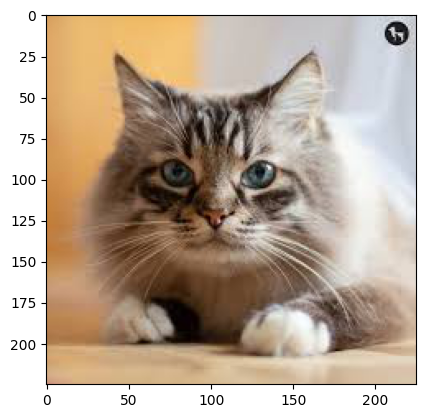

In [26]:
import cv2
import numpy as np
from matplotlib.pyplot import imread
from matplotlib.pyplot import imshow
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.imagenet_utils import decode_predictions
from tensorflow.keras.applications.imagenet_utils import preprocess_input


img_path = r'Downloads\cat.JPEG'

img = cv2.imread(img_path)
img = cv2.resize(img, (240, 240))

x = np.expand_dims(img, axis=0)
x = preprocess_input(x)

print('Input image shape:', x.shape)

my_image = imread(img_path)
imshow(my_image)

In [27]:
preds=model.predict(x)
print("predicted class: ", preds )

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
predicted class:  [[1.14456379e-04 6.62975071e-04 1.11430942e-04 9.88041502e-05
  1.21446188e-04 4.88543534e-04 4.69032166e-05 1.61345350e-04
  1.66429440e-04 9.73055430e-05 1.39714903e-04 1.41653771e-04
  1.44945865e-04 3.84412051e-05 8.45385075e-05 7.80249393e-05
  3.40330065e-04 4.16783732e-04 4.50040534e-05 3.93654409e-05
  5.67375246e-05 8.11440113e-05 4.27582127e-05 1.91661544e-04
  6.58424906e-05 9.53916824e-05 5.87509596e-04 1.03116843e-04
  1.77450172e-04 3.12439544e-04 7.33255365e-05 6.98125586e-05
  1.10920380e-04 1.80522940e-04 1.34027883e-04 2.57303938e-04
  2.99325126e-04 1.25783743e-04 2.33514715e-04 2.35786720e-04
  7.97112225e-05 1.09286564e-04 9.46338623e-05 2.44048104e-04
  1.82034943e-04 3.22484120e-04 1.15654671e-04 1.27202744e-04
  6.02460605e-05 1.89263475e-04 1.11682341e-04 4.42484394e-04
  5.98547158e-05 9.41751496e-05 9.08173170e-05 8.65863694e-05
  1.65094534e-04 8.86898051e-05 1.72856933e-04 2.24819611e-04
  9.70707260e-05

In [28]:
decode_predictions(preds,top=3)

[[('n04493381', 'tub', 0.10745658),
  ('n02123045', 'tabby', 0.089084156),
  ('n02124075', 'Egyptian_cat', 0.08337587)]]

- **EfficientNetB7 Pretrained Model**

In [29]:
from tensorflow.keras.applications import EfficientNetB7
modelb7 = EfficientNetB7(weights='imagenet')

268326632/268326632 ━━━━━━━━━━━━━━━━━━━━ 111s 0us/step


In [30]:
modelb7.summary()

Model: "efficientnetb7"

┏━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃                ┃              ┃  Param ┃               ┃
┃ Layer (type)   ┃ Output Shape ┃      # ┃ Connected to  ┃
┡━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2  │ (None, 600,  │      0 │ -             │
│ (InputLayer)   │ 600, 3)      │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ rescaling_4    │ (None, 600,  │      0 │ input_layer_… │
│ (Rescaling)    │ 600, 3)      │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ normalization… │ (None, 600,  │      7 │ rescaling_4[… │
│ (Normalizatio… │ 600, 3)      │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ rescaling_5    │ (None, 600,  │      0 │ normalizatio… │
│ (Rescaling)    │ 600, 3)      │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ stem_conv_pad  │ (None, 601,  │      0 │ rescaling_5[… │
│ (ZeroPadding2… │ 601, 3)      │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ stem_conv      │ (None, 300,  │  1,728 │ stem_conv_pa… │
│ (Conv2D)       │ 300, 64)     │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ stem_bn        │ (None, 300,  │    256 │ stem_conv[0]… │
│ (BatchNormali… │ 300, 64)     │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ stem_activati… │ (None, 300,  │      0 │ stem_bn[0][0] │
│ (Activation)   │ 300, 64)     │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ block1a_dwconv │ (None, 300,  │    576 │ stem_activat… │
│ (DepthwiseCon… │ 300, 64)     │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ block1a_bn     │ (None, 300,  │    256 │ block1a_dwco… │
│ (BatchNormali… │ 300, 64)     │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ block1a_activ… │ (None, 300,  │      0 │ block1a_bn[0… │
│ (Activation)   │ 300, 64)     │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ block1a_se_sq… │ (None, 64)   │      0 │ block1a_acti… │
│ (GlobalAverag… │              │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ block1a_se_re… │ (None, 1, 1, │      0 │ block1a_se_s… │
│ (Reshape)      │ 64)          │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ block1a_se_re… │ (None, 1, 1, │  1,040 │ block1a_se_r… │
│ (Conv2D)       │ 16)          │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ block1a_se_ex… │ (None, 1, 1, │  1,088 │ block1a_se_r… │
│ (Conv2D)       │ 64)          │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ block1a_se_ex… │ (None, 300,  │      0 │ block1a_acti… │
│ (Multiply)     │ 300, 64)     │        │ block1a_se_e… │
├────────────────┼──────────────┼────────┼───────────────┤
│ block1a_proje… │ (None, 300,  │  2,048 │ block1a_se_e… │
│ (Conv2D)       │ 300, 32)     │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ block1a_proje… │ (None, 300,  │    128 │ block1a_proj… │
│ (BatchNormali… │ 300, 32)     │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ block1b_dwconv │ (None, 300,  │    288 │ block1a_proj… │
│ (DepthwiseCon… │ 300, 32)     │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ block1b_bn     │ (None, 300,  │    128 │ block1b_dwco… │
│ (BatchNormali… │ 300, 32)     │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ block1b_activ… │ (None, 300,  │      0 │ block1b_bn[0… │
│ (Activation)   │ 300, 32)     │        │               │
├────────────────┼──────────────┼────────┼───────────────┤
│ block1b_se_sq… │ (None, 32)   │      0 │ bloc

 Total params: 66,658,687 (254.28 MB)

 Trainable params: 66,347,960 (253.10 MB)

 Non-trainable params: 310,727 (1.19 MB)

Input image shape: (1, 600, 600, 3)


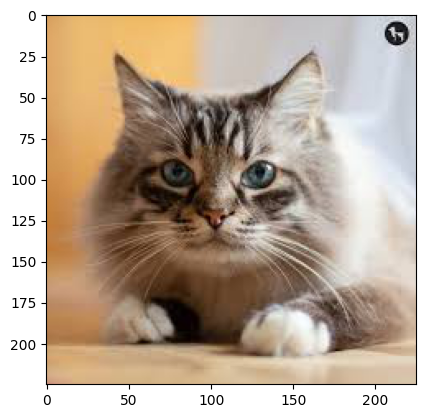

In [31]:
import cv2
import numpy as np
from matplotlib.pyplot import imread
from matplotlib.pyplot import imshow
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.imagenet_utils import decode_predictions
from tensorflow.keras.applications.imagenet_utils import preprocess_input


img_path = r'Downloads\cat.JPEG'

img = cv2.imread(img_path)
img = cv2.resize(img, (600, 600))

x = np.expand_dims(img, axis=0)
x = preprocess_input(x)

print('Input image shape:', x.shape)

my_image = imread(img_path)
imshow(my_image)

In [32]:
predb7=modelb7.predict(x)
print("predicted class: ", predb7 )

1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
predicted class:  [[1.73564025e-04 2.91090138e-04 2.78314343e-04 2.95352453e-04
  1.35189461e-04 1.92102481e-04 1.41940924e-04 1.34587550e-04
  1.48183753e-04 1.16005176e-04 3.71752802e-04 2.15239590e-04
  2.34816078e-04 8.29852070e-05 2.31764760e-04 1.92183754e-04
  9.88945030e-05 1.95669083e-04 1.42371704e-04 6.88382497e-05
  1.08063832e-04 3.18310282e-04 9.45734719e-05 1.37758456e-04
  3.55693250e-04 8.27752810e-05 6.75100164e-05 1.90455816e-04
  1.49110012e-04 1.93337924e-04 1.14399678e-04 3.40949249e-04
  1.01485799e-04 1.08791537e-04 1.45306534e-04 1.19151337e-04
  1.85957615e-04 9.09091323e-05 2.55134393e-04 1.24078520e-04
  1.26291037e-04 1.86882608e-04 1.46079678e-04 1.65526159e-04
  1.52130844e-04 8.88083014e-05 2.98593543e-04 1.07374006e-04
  1.21438308e-04 2.08868601e-04 1.42524048e-04 2.36872831e-04
  1.20452314e-04 1.87797457e-04 4.99051966e-05 3.05143214e-04
  1.12974405e-04 1.57738366e-04 2.44621537e-04 3.53006326e-04
  2.50172190e-

In [33]:
decode_predictions(predb7,top=5)

[[('n02123159', 'tiger_cat', 0.2879238),
  ('n02123045', 'tabby', 0.27976468),
  ('n02124075', 'Egyptian_cat', 0.0805524),
  ('n02127052', 'lynx', 0.020334948),
  ('n02123597', 'Siamese_cat', 0.013059469)]]